<a href="https://colab.research.google.com/github/Zeeshan4511/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Google Search Ranking & Discoverability Capstone

## Refresh / Content Opportunity Scoring

### Project Overview

This capstone explores whether historical search-performance signals can be used to identify content that later experiences a significant decline in Google Search visibility.

The project focuses on the **Refresh / Content Opportunity Scoring** lane. The goal is not to predict Google's ranking algorithm or claim that refreshing a page will directly recover its performance. Instead, the objective is to build a repeatable decision-support workflow that ranks content according to its likelihood of becoming a refresh opportunity based on historical search-performance patterns.

The analysis uses anonymized FlyRank search-performance data and follows a retrospective historical-versus-future evaluation design. Historical performance from November 2025 through March 2026 is used to construct features, while performance from April through June 2026 is used to define the outcome.

The final workflow compares a transparent historical-trend baseline with Logistic Regression and Random Forest models, validates the models using a client-grouped holdout split, checks for future-data leakage, and produces a ranked content recommendation queue.

### Main Question

> Can historical search-performance signals help prioritize content that is likely to experience a substantial future decline in search impressions?

### Decision Supported

The analysis is designed to support a practical content-management decision:

> **Which content should be reviewed or considered for refresh first?**

The resulting scores are intended as prioritization signals for human review rather than automatic instructions to change content.

In [ ]:
from google.colab import userdata
from huggingface_hub import login

login(token=userdata.get("HF_TOKEN"))

In [ ]:
from datasets import load_dataset

dim_clients = load_dataset(
    "FlyRank/internship-warehouse",
    "dim_clients"
)

dim_content = load_dataset(
    "FlyRank/internship-warehouse",
    "dim_content"
)

fact_daily = load_dataset(
    "FlyRank/internship-warehouse",
    "fact_content_daily_performance"
)

fact_query = load_dataset(
    "FlyRank/internship-warehouse",
    "fact_content_query_90d"
)

README.md:   0%|          | 0.00/3.04k [00:00<?, ?B/s]

dim_clients.parquet: reconstructing file:   0%|          |  0.00B / 3.38kB            

dim_clients.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/104 [00:00<?, ? examples/s]

dim_content.parquet: reconstructing file:   0%|          |  0.00B / 19.6MB            

...

Generating train split:   0%|          | 0/78835655 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/39 [00:00<?, ?it/s]

fact_content_query_90d.parquet: reconstructing file:   0%|          |  0.00B / 60.7MB            

fact_content_query_90d.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2414248 [00:00<?, ? examples/s]

In [ ]:
fact_daily["train"].column_names

['report_date',
 'client_hash_id',
 'content_hash_id',
 'client_has_gsc',
 'client_has_ga4',
 'gsc_data_available',
 'ga4_data_available',
 'gsc_impressions',
 'gsc_clicks',
 'gsc_sum_position',
 'gsc_avg_position',
 'ga4_pageviews',
 'ga4_sessions',
 'ga4_users',
 'ga4_engaged_sessions',
 'ga4_total_engagement_sec',
 'sessions_organic',
 'sessions_direct',
 'sessions_referral',
 'sessions_social',
 'sessions_paid',
 'sessions_ai',
 'ai_chatgpt',
 'ai_perplexity',
 'ai_gemini',
 'ai_copilot',
 'ai_claude',
 'ai_meta',
 'ai_other',
 'scroll_events']

## 1. Data Source and Dataset Overview

The analysis uses the FlyRank internship warehouse, which contains anonymized search and content-performance data. The dataset is designed for applied Search Intelligence and ML experimentation.

Four tables were loaded:

- `dim_clients` — client-level reference information.
- `dim_content` — content-level reference information.
- `fact_content_daily_performance` — daily search and engagement performance metrics.
- `fact_content_query_90d` — query-level search-performance information.

For this capstone, the main modeling analysis uses the daily content-performance table because it provides the historical Google Search metrics required to construct monthly performance features.

The data contains pseudonymized client and content identifiers. No client names, domains, URLs, private search queries, credentials, or raw private exports are included in the public analysis.

The FlyRank starter materials emphasize that public work should remain anonymized and should be framed as observed, measured, directional, or decision-support analysis rather than claims about Google's ranking algorithm. :contentReference[oaicite:1]{index=1}

In [ ]:
import pandas as pd

sample = pd.DataFrame(fact_daily["train"][:100000])

# Convert 'report_date' to datetime and extract the month in 'YYYY-MM' format
sample["month"] = pd.to_datetime(sample["report_date"]).dt.strftime('%Y-%m')

march = sample[sample["month"] == "2026-03"]

march.head()

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month


## 2. Dataset Coverage

The daily performance table contains approximately **78.8 million rows** covering the period from **January 27, 2025 through June 30, 2026**.

Because the daily table is very large, the analysis does not attempt to keep the complete dataset in a single modeling dataframe. Instead, the required search-performance fields are processed in chunks and aggregated to monthly content-client observations.

This reduces the data to a more manageable analytical level while preserving the historical trend information required for the capstone.

The resulting monthly dataset contains approximately **15.2 million content-client-month observations**.

In [ ]:
train = fact_daily["train"]

print("Total rows:", train.num_rows)
print("Number of columns:", len(train.column_names))

print("\nFirst 10 dates:")
print(train["report_date"][:10])

print("\nLast 10 dates:")
print(train["report_date"][-10:])

Total rows: 78835655
Number of columns: 30

First 10 dates:
[datetime.date(2025, 1, 27), datetime.date(2025, 1, 27), datetime.date(2025, 1, 27), datetime.date(2025, 1, 27), datetime.date(2025, 1, 27), datetime.date(2025, 1, 27), datetime.date(2025, 1, 27), datetime.date(2025, 1, 27), datetime.date(2025, 1, 27), datetime.date(2025, 1, 27)]

Last 10 dates:
[datetime.date(2026, 6, 30), datetime.date(2026, 6, 30), datetime.date(2026, 6, 30), datetime.date(2026, 6, 30), datetime.date(2026, 6, 30), datetime.date(2026, 6, 30), datetime.date(2026, 6, 30), datetime.date(2026, 6, 30), datetime.date(2026, 6, 30), datetime.date(2026, 6, 30)]


In [ ]:
import pandas as pd

train = fact_daily["train"]

positions = [
    0,
    100000,
    1000000,
    10000000,
    30000000,
    50000000,
    70000000,
    train.num_rows - 100000
]

for pos in positions:
    sample = pd.DataFrame(train[pos:pos+100000])
    dates = pd.to_datetime(sample["report_date"])

    print(
        f"Rows {pos:,} - {min(pos+100000, train.num_rows):,}: "
        f"{dates.min().date()} to {dates.max().date()}"
    )

Rows 0 - 100,000: 2025-01-27 to 2025-03-21
Rows 100,000 - 200,000: 2025-03-01 to 2025-03-31
Rows 1,000,000 - 1,100,000: 2025-06-01 to 2025-06-30
Rows 10,000,000 - 10,100,000: 2025-11-15 to 2025-11-23
Rows 30,000,000 - 30,100,000: 2026-02-05 to 2026-02-14
Rows 50,000,000 - 50,100,000: 2026-04-15 to 2026-04-17
Rows 70,000,000 - 70,100,000: 2026-06-06 to 2026-06-10
Rows 78,735,655 - 78,835,655: 2026-06-28 to 2026-06-30


In [ ]:
sample = pd.DataFrame(train[:100000])

print(sample[
    [
        "client_has_gsc",
        "gsc_data_available",
        "gsc_impressions",
        "gsc_clicks",
        "gsc_avg_position"
    ]
].head(20))

    client_has_gsc  gsc_data_available  gsc_impressions  gsc_clicks  \
0             True                True               30           0   
1             True                True                5           0   
2             True                True                1           0   
3             True                True                6           0   
4             True                True                5           0   
5             True                True               21           0   
6             True                True               13           0   
7             True                True               29           0   
8             True                True                5           0   
9             True                True                8           0   
10            True                True               32           0   
11            True                True               32           0   
12            True                True                3           0   
13    

In [ ]:
print("\nGSC availability:")
print(sample["gsc_data_available"].value_counts(dropna=False))

print("\nClients with GSC:")
print(sample["client_has_gsc"].value_counts(dropna=False))


GSC availability:
gsc_data_available
True    100000
Name: count, dtype: int64

Clients with GSC:
client_has_gsc
True    100000
Name: count, dtype: int64


In [ ]:
print(sample[
    [
        "gsc_impressions",
        "gsc_clicks",
        "gsc_avg_position"
    ]
].describe())

       gsc_impressions     gsc_clicks  gsc_avg_position
count    100000.000000  100000.000000      99999.000000
mean         17.000510       0.114610         28.890156
std          29.472032       0.503147         22.812135
min           1.000000       0.000000          0.000000
25%           3.000000       0.000000          9.298438
50%           8.000000       0.000000         22.000000
75%          20.000000       0.000000         43.750000
max         945.000000      33.000000        204.000000


## 3. Monthly Aggregation

The raw performance data is recorded at a daily level. For this project, the decision is whether a content item should be prioritized for a potential refresh based on sustained historical performance.

Daily observations are therefore aggregated to the **content-client-month** level.

For each month and content-client combination, the analysis calculates:

- Total impressions
- Total clicks
- Mean average search position

Only observations with available Google Search Console data are included in the aggregation.

Monthly aggregation provides a consistent time unit for comparing the historical period with the future evaluation period.

In [ ]:
import pandas as pd

train = fact_daily["train"]

# Select only columns needed for the capstone
columns_needed = [
    "report_date",
    "client_hash_id",
    "content_hash_id",
    "gsc_data_available",
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position"
]

# Take the dataset in chunks and aggregate each chunk
chunk_size = 500000
monthly_chunks = []

for start in range(0, train.num_rows, chunk_size):
    end = min(start + chunk_size, train.num_rows)

    chunk = pd.DataFrame(
        train[start:end],
        columns=columns_needed
    )

    chunk["report_date"] = pd.to_datetime(chunk["report_date"])
    chunk["month"] = chunk["report_date"].dt.to_period("M")

    # Keep records with usable GSC data
    chunk = chunk[chunk["gsc_data_available"] == True]

    monthly = (
        chunk.groupby(
            ["month", "client_hash_id", "content_hash_id"],
            as_index=False
        )
        .agg(
            impressions=("gsc_impressions", "sum"),
            clicks=("gsc_clicks", "sum"),
            avg_position=("gsc_avg_position", "mean")
        )
    )

    monthly_chunks.append(monthly)

    if (start // chunk_size + 1) % 10 == 0:
        print(f"Processed {end:,} / {train.num_rows:,} rows")

monthly_data = pd.concat(monthly_chunks, ignore_index=True)

print("Monthly rows:", len(monthly_data))
print("Months:", monthly_data["month"].min(), "to", monthly_data["month"].max())
print(monthly_data.head())

Processed 5,000,000 / 78,835,655 rows
Processed 10,000,000 / 78,835,655 rows
Processed 15,000,000 / 78,835,655 rows
Processed 20,000,000 / 78,835,655 rows
Processed 25,000,000 / 78,835,655 rows
Processed 30,000,000 / 78,835,655 rows
Processed 35,000,000 / 78,835,655 rows
Processed 40,000,000 / 78,835,655 rows
Processed 45,000,000 / 78,835,655 rows
Processed 50,000,000 / 78,835,655 rows
Processed 55,000,000 / 78,835,655 rows
Processed 60,000,000 / 78,835,655 rows
Processed 65,000,000 / 78,835,655 rows
Processed 70,000,000 / 78,835,655 rows
Processed 75,000,000 / 78,835,655 rows
Monthly rows: 15221972
Months: 2025-01 to 2026-06
     month           client_hash_id           content_hash_id  impressions  \
0  2025-01  client_9958f0a7ae1df715  content_0217be03126aa7a5        119.0   
1  2025-01  client_9958f0a7ae1df715  content_0642dc7f62d4f780         53.0   
2  2025-01  client_9958f0a7ae1df715  content_0672d8db776419c0         25.0   
3  2025-01  client_9958f0a7ae1df715  content_0ca502c18

### Monthly Dataset Result

After processing the daily data in chunks and aggregating it by month, client, and content item, the resulting dataset contains approximately **15.2 million monthly observations**.

The monthly dataset covers January 2025 through June 2026. The later months contain more observations because the available content-performance coverage increases over time.

This monthly representation is used for all subsequent historical and future-window calculations.

In [ ]:
print(monthly_data.info())

print("\nNumber of unique contents:",
      monthly_data["content_hash_id"].nunique())

print("\nNumber of unique clients:",
      monthly_data["client_hash_id"].nunique())

print("\nMonthly record counts:")
print(monthly_data["month"].value_counts().sort_index())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15221972 entries, 0 to 15221971
Data columns (total 6 columns):
 #   Column           Dtype    
---  ------           -----    
 0   month            period[M]
 1   client_hash_id   object   
 2   content_hash_id  object   
 3   impressions      float64  
 4   clicks           float64  
 5   avg_position     float64  
dtypes: float64(3), object(2), period[M](1)
memory usage: 696.8+ MB
None

Number of unique contents: 309234

Number of unique clients: 67

Monthly record counts:
month
2025-01        476
2025-02       5903
2025-03      10374
2025-04      24946
2025-05      14887
2025-06      31159
2025-07      52428
2025-08      70379
2025-09     138205
2025-10     260240
2025-11     853238
2025-12    1093301
2026-01    1274426
2026-02    1421349
2026-03    2111554
2026-04    2406184
2026-05    2875692
2026-06    2577231
Freq: M, Name: count, dtype: int64


In [ ]:
content_history = (
    monthly_data
    .groupby(["client_hash_id", "content_hash_id"])
    .agg(
        months_observed=("month", "nunique"),
        first_month=("month", "min"),
        last_month=("month", "max"),
        total_impressions=("impressions", "sum"),
        total_clicks=("clicks", "sum")
    )
    .reset_index()
)

print("Total content-client combinations:",
      len(content_history))

print("\nMonths observed distribution:")
print(content_history["months_observed"].describe())

print("\nContent with at least 3 months:")
print(
    (content_history["months_observed"] >= 3).sum()
)

print("\nContent with at least 6 months:")
print(
    (content_history["months_observed"] >= 6).sum()
)

print("\nContent with at least 9 months:")
print(
    (content_history["months_observed"] >= 9).sum()
)

print("\nSample:")
print(content_history.head())

Total content-client combinations: 309234

Months observed distribution:
count    309234.000000
mean          5.000925
std           3.795305
min           1.000000
25%           2.000000
50%           4.000000
75%           7.000000
max          18.000000
Name: months_observed, dtype: float64

Content with at least 3 months:
212873

Content with at least 6 months:
99616

Content with at least 9 months:
53839

Sample:
            client_hash_id           content_hash_id  months_observed  \
0  client_06d356715a8ff3b6  content_0058bd88fb1821f2                1   
1  client_06d356715a8ff3b6  content_0059a4d4195810c9                3   
2  client_06d356715a8ff3b6  content_005b6b7f7b8dda7f                3   
3  client_06d356715a8ff3b6  content_0094c7d0fbcc07b7                2   
4  client_06d356715a8ff3b6  content_00a34394d4ee05ce                2   

  first_month last_month  total_impressions  total_clicks  
0     2026-06    2026-06              241.0           1.0  
1     2026-04    20

## 4. Content History Coverage

Before defining the modeling population, the analysis checks how many months of historical observations are available for each content-client combination.

This step is important because a content item with only one month of observations provides very limited information about its historical trend. Requiring multiple months of history makes the resulting features more meaningful and reduces the risk of treating a single unusual month as a trend.

The history coverage analysis shows that:

- 309,234 content-client combinations are available.
- The median number of observed months is 4.
- 212,873 combinations have at least 3 months of observations.
- 99,616 combinations have at least 6 months of observations.

For the capstone, a minimum of **three historical months** is required for the modeling population.

In [ ]:
eligible_content = content_history[
    content_history["months_observed"] >= 6
].copy()

print("Eligible content-client combinations:",
      len(eligible_content))

print("\nTotal impressions:")
print(eligible_content["total_impressions"].describe())

print("\nTotal clicks:")
print(eligible_content["total_clicks"].describe())

Eligible content-client combinations: 99616

Total impressions:
count    9.961600e+04
mean     1.355272e+04
std      4.034437e+04
min      6.000000e+00
25%      4.570000e+02
50%      2.449500e+03
75%      1.088100e+04
max      2.902616e+06
Name: total_impressions, dtype: float64

Total clicks:
count    99616.000000
mean        44.181045
std        207.716761
min          0.000000
25%          0.000000
50%          3.000000
75%         23.000000
max      24747.000000
Name: total_clicks, dtype: float64


## 5. Historical and Future Evaluation Windows

To avoid using future information when constructing historical features, the analysis separates the timeline into two periods.

### Historical period
**November 2025 – March 2026**

This period is used to calculate the features available before the outcome period.

### Future evaluation period
**April 2026 – June 2026**

This period is kept separate and is used only to measure what happened after the historical period.

This temporal separation is important because the model should learn from information that would have been available before the measured deterioration.

The historical period contains approximately **6.75 million monthly observations**, while the future period contains approximately **7.86 million monthly observations**.

In [ ]:
# Convert month to timestamp for easy filtering
monthly_data["month_date"] = monthly_data["month"].dt.to_timestamp()

# Historical period
history = monthly_data[
    (monthly_data["month_date"] >= "2025-11-01") &
    (monthly_data["month_date"] <= "2026-03-01")
].copy()

# Future period
future = monthly_data[
    (monthly_data["month_date"] >= "2026-04-01") &
    (monthly_data["month_date"] <= "2026-06-01")
].copy()

print("Historical rows:", len(history))
print("Future rows:", len(future))

print("\nHistorical months:")
print(sorted(history["month"].unique()))

print("\nFuture months:")
print(sorted(future["month"].unique()))

Historical rows: 6753868
Future rows: 7859107

Historical months:
[Period('2025-11', 'M'), Period('2025-12', 'M'), Period('2026-01', 'M'), Period('2026-02', 'M'), Period('2026-03', 'M')]

Future months:
[Period('2026-04', 'M'), Period('2026-05', 'M'), Period('2026-06', 'M')]


## 6. Historical Feature Engineering

The next step converts the historical monthly observations into one feature vector for each eligible content-client combination.

The features describe the content's historical search visibility, click activity, search position, click-through rate, and changes in performance over time.

The main feature groups are:

1. **Volume features** — total impressions and total clicks.
2. **Position features** — average, first, and last observed search position.
3. **CTR features** — historical average click-through rate.
4. **Trend features** — change between the first and last observed historical observations.
5. **History coverage** — number of historical months available.

The objective is to represent the historical state and direction of each content item without using information from the future outcome period.

In [ ]:
# Create CTR
history["ctr"] = (
    history["clicks"] /
    history["impressions"].replace(0, pd.NA)
)

# Aggregate historical performance for each content item
historical_features = (
    history
    .groupby(["client_hash_id", "content_hash_id"])
    .agg(
        history_months=("month", "nunique"),
        total_impressions=("impressions", "sum"),
        total_clicks=("clicks", "sum"),
        avg_position=("avg_position", "mean"),
        avg_ctr=("ctr", "mean")
    )
    .reset_index()
)

# Require at least 3 months of historical observations
historical_features = historical_features[
    historical_features["history_months"] >= 3
].copy()

print("Historical eligible content:",
      len(historical_features))

print(historical_features.head())

Historical eligible content: 118082
            client_hash_id           content_hash_id  history_months  \
0  client_0797ff3a1fc9a6a5  content_0263d5f9b7a2ecd4               3   
2  client_0797ff3a1fc9a6a5  content_04c67f3541177192               5   
3  client_0797ff3a1fc9a6a5  content_05acc92c165f4386               5   
4  client_0797ff3a1fc9a6a5  content_0b33d8960857ad90               4   
5  client_0797ff3a1fc9a6a5  content_0f30e04e709c7b5d               5   

   total_impressions  total_clicks  avg_position   avg_ctr  
0               69.0           0.0      9.427891  0.000000  
2             1087.0           8.0     14.259342  0.006567  
3              518.0           1.0      9.510943  0.002024  
4               42.0           0.0     10.541667  0.000000  
5              514.0           1.0      8.941854  0.001563  


### Historical Feature Population

After requiring at least three months of historical observations, **118,082 content-client combinations** remain eligible for feature construction.

The historical data shows substantial variation in search visibility. Some content items have only a small number of impressions, while others have accumulated very large impression volumes.

This variation is useful for the opportunity-scoring problem because the model needs to distinguish between normal low-volume content and content showing meaningful deterioration from an established historical level.

In [ ]:
# Sort historical data chronologically
history_sorted = history.sort_values(
    ["client_hash_id", "content_hash_id", "month"]
)

# Calculate first and last observed performance
trend_features = (
    history_sorted
    .groupby(["client_hash_id", "content_hash_id"])
    .agg(
        first_impressions=("impressions", "first"),
        last_impressions=("impressions", "last"),
        first_clicks=("clicks", "first"),
        last_clicks=("clicks", "last"),
        first_position=("avg_position", "first"),
        last_position=("avg_position", "last")
    )
    .reset_index()
)

# Calculate relative changes
trend_features["impression_change"] = (
    (trend_features["last_impressions"] -
     trend_features["first_impressions"])
    / trend_features["first_impressions"].replace(0, pd.NA)
)

trend_features["click_change"] = (
    (trend_features["last_clicks"] -
     trend_features["first_clicks"])
    / trend_features["first_clicks"].replace(0, pd.NA)
)

trend_features["position_change"] = (
    trend_features["last_position"] -
    trend_features["first_position"]
)

print(trend_features.head())

            client_hash_id           content_hash_id  first_impressions  \
0  client_0797ff3a1fc9a6a5  content_0263d5f9b7a2ecd4                2.0   
1  client_0797ff3a1fc9a6a5  content_0317b24cc1ff5c5d                1.0   
2  client_0797ff3a1fc9a6a5  content_04c67f3541177192               38.0   
3  client_0797ff3a1fc9a6a5  content_05acc92c165f4386               13.0   
4  client_0797ff3a1fc9a6a5  content_0b33d8960857ad90                1.0   

   last_impressions  first_clicks  last_clicks  first_position  last_position  \
0               1.0           0.0          0.0       10.500000       9.000000   
1               1.0           0.0          0.0        4.000000      12.000000   
2              14.0           0.0          0.0        8.441621      16.833333   
3               9.0           1.0          0.0        8.625000       9.375000   
4               1.0           0.0          0.0       12.000000      10.000000   

   impression_change click_change  position_change  
0        

## 7. Historical Trend Features

In addition to aggregate historical performance, the analysis calculates directional features by comparing the first and last observations within the historical period.

The main trend variables are:

- `impression_change` — relative change in impressions from the first to the last historical observation.
- `click_change` — relative change in clicks.
- `position_change` — difference between the last and first search position.

For search position, **lower values represent better positions**. Therefore, a positive position change generally indicates deterioration, while a negative change indicates improvement.

The `click_change` feature is excluded from the final modeling feature set because the first historical click count is zero for most observations, which creates substantial missingness in the relative-change calculation.

In [ ]:
model_data = historical_features.merge(
    trend_features,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print("Model rows:", len(model_data))
print("Model columns:")
print(model_data.columns.tolist())

print("\nMissing values:")
print(model_data.isna().sum())

Model rows: 118082
Model columns:
['client_hash_id', 'content_hash_id', 'history_months', 'total_impressions', 'total_clicks', 'avg_position', 'avg_ctr', 'first_impressions', 'last_impressions', 'first_clicks', 'last_clicks', 'first_position', 'last_position', 'impression_change', 'click_change', 'position_change']

Missing values:
client_hash_id            0
content_hash_id           0
history_months            0
total_impressions         0
total_clicks              0
avg_position              0
avg_ctr                   0
first_impressions         0
last_impressions          0
first_clicks              0
last_clicks               0
first_position            0
last_position             0
impression_change         0
click_change         106615
position_change           0
dtype: int64


In [ ]:
print(model_data.describe())

       history_months  total_impressions   total_clicks   avg_position  \
count   118082.000000      118082.000000  118082.000000  118082.000000   
mean         4.393405        6062.376493      19.079284      15.065692   
std          0.817316       18576.986022     102.558465      14.170900   
min          3.000000           3.000000       0.000000       0.000000   
25%          4.000000         109.000000       0.000000       5.770521   
50%          5.000000         782.000000       1.000000       9.802962   
75%          5.000000        4385.000000       8.000000      18.912388   
max          5.000000      916030.000000   11245.000000     232.305556   

             avg_ctr  first_impressions  last_impressions   first_clicks  \
count  118082.000000      118082.000000     118082.000000  118082.000000   
mean        0.005411          56.668518        109.320633       0.214317   
std         0.021735         235.486111        469.337183       1.367107   
min         0.000000         

## 8. Defining the Future Outcome

The future period is used only to measure subsequent performance.

For each content-client combination, the analysis calculates:

- Future impressions
- Future clicks
- Future average position
- Future average CTR
- Number of future months observed

To make the outcome comparable across content items, total future impressions are converted into an average monthly impression level.

The same calculation is applied to the historical period.

This creates a relative measure of how future monthly search visibility compares with the historical monthly baseline.

In [ ]:
# Calculate future CTR
future["ctr"] = (
    future["clicks"] /
    future["impressions"].replace(0, pd.NA)
)

# Aggregate future performance
future_outcomes = (
    future
    .groupby(["client_hash_id", "content_hash_id"])
    .agg(
        future_months=("month", "nunique"),
        future_impressions=("impressions", "sum"),
        future_clicks=("clicks", "sum"),
        future_avg_position=("avg_position", "mean"),
        future_avg_ctr=("ctr", "mean")
    )
    .reset_index()
)

print("Future content-client combinations:",
      len(future_outcomes))

print("\nFuture months distribution:")
print(future_outcomes["future_months"].value_counts().sort_index())

print("\nFuture performance:")
print(
    future_outcomes[
        [
            "future_impressions",
            "future_clicks",
            "future_avg_position",
            "future_avg_ctr"
        ]
    ].describe()
)

Future content-client combinations: 271046

Future months distribution:
future_months
1     57448
2     56936
3    156662
Name: count, dtype: int64

Future performance:
       future_impressions  future_clicks  future_avg_position  future_avg_ctr
count        2.710460e+05  271046.000000        271046.000000   271046.000000
mean         2.857179e+03      10.970758            19.217003        0.005407
std          1.304771e+04     405.866217            18.974379        0.023814
min          1.000000e+00       0.000000             0.000000        0.000000
25%          1.600000e+01       0.000000             6.328468        0.000000
50%          1.700000e+02       0.000000            12.079825        0.000000
75%          1.267000e+03       3.000000            26.350589        0.003017
max          1.986586e+06  152170.000000           302.000000        1.000000


## 9. Complete Future Observation Requirement

The future evaluation window covers three months: April, May, and June 2026.

Only content-client combinations with observations in **all three future months** are retained for final modeling.

This requirement prevents a content item with only one future month from being compared directly with content having a complete three-month outcome period.

After applying this requirement and matching the historical feature population to the complete future outcomes, **85,514 observations** remain for final modeling.

In [ ]:
future_complete = future_outcomes[
    future_outcomes["future_months"] == 3
].copy()

print("Content with all 3 future months:",
      len(future_complete))

Content with all 3 future months: 156662


In [ ]:
model_data = model_data.merge(
    future_complete,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print("Final modeling candidates:",
      len(model_data))

print("\nMissing values:")
print(model_data.isna().sum())

Final modeling candidates: 85514

Missing values:
client_hash_id             0
content_hash_id            0
history_months             0
total_impressions          0
total_clicks               0
avg_position               0
avg_ctr                    0
first_impressions          0
last_impressions           0
first_clicks               0
last_clicks                0
first_position             0
last_position              0
impression_change          0
click_change           74914
position_change            0
future_months              0
future_impressions         0
future_clicks              0
future_avg_position        0
future_avg_ctr             0
dtype: int64


## 10. Outcome Definition

The primary outcome is based on the change in average monthly impressions between the historical and future periods.

The formula is:

**Future Impression Change = (Future Average Monthly Impressions − Historical Average Monthly Impressions) / Historical Average Monthly Impressions**

A negative value means that future search visibility was lower than the historical level.

For this capstone, a **Refresh Opportunity** is defined as a content item whose future average monthly impressions declined by at least **50%** compared with its historical average.

### Target definition

- `1` = Refresh Opportunity
- `0` = Not a Refresh Opportunity

The 50% threshold represents a substantial deterioration in observed search visibility and creates a clear operational definition for prioritization.

This label is retrospective. It identifies content that experienced a large subsequent decline; it does not prove that refreshing the content would have prevented or reversed that decline.

In [ ]:
model_data["historical_avg_monthly_impressions"] = (
    model_data["total_impressions"] /
    model_data["history_months"]
)

model_data["future_avg_monthly_impressions"] = (
    model_data["future_impressions"] /
    model_data["future_months"]
)

model_data["future_impression_change"] = (
    (
        model_data["future_avg_monthly_impressions"]
        -
        model_data["historical_avg_monthly_impressions"]
    )
    /
    model_data["historical_avg_monthly_impressions"]
)

In [ ]:
print(
    model_data["future_impression_change"].describe()
)

count    85514.000000
mean         0.465215
std          4.390633
min         -0.999386
25%         -0.545301
50%         -0.125852
75%          0.536797
max        627.166667
Name: future_impression_change, dtype: float64


In [ ]:
print(
    model_data[
        [
            "historical_avg_monthly_impressions",
            "future_avg_monthly_impressions",
            "future_impression_change"
        ]
    ].head(20)
)

    historical_avg_monthly_impressions  future_avg_monthly_impressions  \
0                                23.00                       10.666667   
1                               217.40                     2698.666667   
2                               231.20                     2160.666667   
3                                33.40                       15.000000   
4                               145.80                     1379.000000   
5                                25.20                       53.000000   
6                               968.20                     7870.333333   
7                               251.00                      669.000000   
8                                37.80                      923.666667   
9                               325.80                     3481.333333   
10                             2454.60                     5067.666667   
11                               14.20                       22.000000   
12                             1166.00

In [ ]:
print("Future impression change distribution:")

print(
    model_data["future_impression_change"]
    .quantile(
        [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

Future impression change distribution:
0.01   -0.953314
0.05   -0.857474
0.10   -0.767700
0.25   -0.545301
0.50   -0.125852
0.75    0.536797
0.90    1.745385
0.95    3.081424
0.99    9.257867
Name: future_impression_change, dtype: float64


### Target Distribution

The final dataset contains **85,514 modeling observations**.

The target distribution is:

- **61,555 observations (72.0%)** — Not a Refresh Opportunity
- **23,959 observations (28.0%)** — Refresh Opportunity

The target is therefore imbalanced, although the minority class is large enough to support supervised classification.

Because this is primarily a ranking problem, the evaluation focuses not only on classification metrics but also on how effectively the model concentrates refresh opportunities near the top of the ranked list.

In [ ]:
model_data["refresh_opportunity"] = (
    model_data["future_impression_change"] <= -0.50
).astype(int)

print(
    model_data["refresh_opportunity"].value_counts()
)

print("\nPercentage:")
print(
    model_data["refresh_opportunity"]
    .value_counts(normalize=True)
    .mul(100)
)

refresh_opportunity
0    61555
1    23959
Name: count, dtype: int64

Percentage:
refresh_opportunity
0    71.982365
1    28.017635
Name: proportion, dtype: float64


In [ ]:
print(
    model_data[
        [
            "historical_avg_monthly_impressions",
            "future_avg_monthly_impressions",
            "future_impression_change",
            "refresh_opportunity"
        ]
    ].head(20)
)

    historical_avg_monthly_impressions  future_avg_monthly_impressions  \
0                                23.00                       10.666667   
1                               217.40                     2698.666667   
2                               231.20                     2160.666667   
3                                33.40                       15.000000   
4                               145.80                     1379.000000   
5                                25.20                       53.000000   
6                               968.20                     7870.333333   
7                               251.00                      669.000000   
8                                37.80                      923.666667   
9                               325.80                     3481.333333   
10                             2454.60                     5067.666667   
11                               14.20                       22.000000   
12                             1166.00

In [ ]:
target_summary = (
    model_data
    .groupby("refresh_opportunity")
    .agg(
        content_count=("content_hash_id", "count"),
        avg_historical_impressions=(
            "historical_avg_monthly_impressions",
            "mean"
        ),
        avg_future_impressions=(
            "future_avg_monthly_impressions",
            "mean"
        ),
        avg_future_change=(
            "future_impression_change",
            "mean"
        )
    )
    .reset_index()
)

print(target_summary)

   refresh_opportunity  content_count  avg_historical_impressions  \
0                    0          61555                 1806.706772   
1                    1          23959                 1462.847027   

   avg_future_impressions  avg_future_change  
0             2280.112425           0.924785  
1              423.483827          -0.715503  


## 11. Model Features

The final model uses 13 historical features:

- History months
- Total impressions
- Total clicks
- Average position
- Average CTR
- First impressions
- Last impressions
- First clicks
- Last clicks
- First position
- Last position
- Historical impression change
- Historical position change

All selected features are derived from the historical period only.

The future outcome variables are intentionally excluded from the feature matrix.

In [ ]:
model_features = [
    "history_months",
    "total_impressions",
    "total_clicks",
    "avg_position",
    "avg_ctr",
    "first_impressions",
    "last_impressions",
    "first_clicks",
    "last_clicks",
    "first_position",
    "last_position",
    "impression_change",
    "position_change"
]

X = model_data[model_features].copy()
y = model_data["refresh_opportunity"].copy()

print("Features:")
print(X.columns.tolist())

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

print("\nMissing values:")
print(X.isna().sum())

Features:
['history_months', 'total_impressions', 'total_clicks', 'avg_position', 'avg_ctr', 'first_impressions', 'last_impressions', 'first_clicks', 'last_clicks', 'first_position', 'last_position', 'impression_change', 'position_change']

Feature shape: (85514, 13)
Target shape: (85514,)

Missing values:
history_months       0
total_impressions    0
total_clicks         0
avg_position         0
avg_ctr              0
first_impressions    0
last_impressions     0
first_clicks         0
last_clicks          0
first_position       0
last_position        0
impression_change    0
position_change      0
dtype: int64


In [ ]:
print("Target distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(y.value_counts(normalize=True).mul(100))

Target distribution:
refresh_opportunity
0    61555
1    23959
Name: count, dtype: int64

Target percentage:
refresh_opportunity
0    71.982365
1    28.017635
Name: proportion, dtype: float64


## 12. Transparent Historical-Trend Baseline

Before training a machine-learning model, a simple baseline is established.

The baseline uses the historical impression trend directly. Content with a larger historical decline receives a higher opportunity score.

This provides an important benchmark because a machine-learning model should demonstrate value beyond an understandable rule.

The baseline is intentionally simple and transparent:

> **Greater historical impression decline → higher refresh priority**

The baseline achieves an Average Precision of **0.5097** and a ROC-AUC of **0.6744**.

At the very top of the ranking, the baseline is already strong, achieving approximately **98% Precision@100** and **94.8% Precision@500**.

This makes the baseline a meaningful benchmark rather than a weak comparison.

In [ ]:
from sklearn.metrics import average_precision_score, roc_auc_score

baseline_score = -model_data["impression_change"]

baseline_ap = average_precision_score(
    model_data["refresh_opportunity"],
    baseline_score
)

baseline_auc = roc_auc_score(
    model_data["refresh_opportunity"],
    baseline_score
)

print("Baseline Average Precision:", round(baseline_ap, 4))
print("Baseline ROC-AUC:", round(baseline_auc, 4))

Baseline Average Precision: 0.5097
Baseline ROC-AUC: 0.6744


In [ ]:
baseline_ranking = model_data[
    [
        "client_hash_id",
        "content_hash_id",
        "impression_change",
        "refresh_opportunity"
    ]
].copy()

baseline_ranking["baseline_score"] = -baseline_ranking["impression_change"]

baseline_ranking = baseline_ranking.sort_values(
    "baseline_score",
    ascending=False
)

precision_at_100 = (
    baseline_ranking.head(100)["refresh_opportunity"].mean()
)

precision_at_500 = (
    baseline_ranking.head(500)["refresh_opportunity"].mean()
)

print("Baseline Precision@100:", round(precision_at_100, 4))
print("Baseline Precision@500:", round(precision_at_500, 4))

Baseline Precision@100: 0.98
Baseline Precision@500: 0.948


## 13. Validation Strategy

A standard random row-level split could place observations from the same client in both training and testing data. That could make performance appear stronger because the model would see related client-specific patterns during training.

To reduce this risk, the analysis uses a **client-grouped train/test split**.

The client identifier is used only for grouping and is not used as a model feature.

The resulting split contains:

- **77,942 training observations**
- **7,572 testing observations**
- **20 training clients**
- **6 testing clients**

There is **zero client overlap** between the training and testing sets.

The different class proportions between training and testing are retained rather than adjusting the split after seeing the results. This is reported as a limitation of the grouped validation design.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        X,
        y,
        groups=model_data["client_hash_id"]
    )
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).mul(100))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).mul(100))

print("\nUnique clients in training:",
      model_data.iloc[train_idx]["client_hash_id"].nunique())

print("Unique clients in testing:",
      model_data.iloc[test_idx]["client_hash_id"].nunique())

Training rows: 77942
Testing rows: 7572

Training target distribution:
refresh_opportunity
0    73.694542
1    26.305458
Name: proportion, dtype: float64

Testing target distribution:
refresh_opportunity
0    54.358162
1    45.641838
Name: proportion, dtype: float64

Unique clients in training: 20
Unique clients in testing: 6


In [ ]:
train_clients = set(
    model_data.iloc[train_idx]["client_hash_id"]
)

test_clients = set(
    model_data.iloc[test_idx]["client_hash_id"]
)

overlap = train_clients.intersection(test_clients)

print("Client overlap:", len(overlap))

Client overlap: 0


## 14. Logistic Regression

Logistic Regression is used as the first machine-learning benchmark.

Because the features have different numerical scales, StandardScaler is applied before fitting the model.

The model produces a probability-like score representing the estimated likelihood of the refresh-opportunity class.

Logistic Regression improves over the historical baseline in overall ranking performance, achieving:

- Average Precision: **0.6458**
- ROC-AUC: **0.6973**

However, its default 0.5 classification threshold produces very low recall. This reinforces an important point for this project: the main use case is **ranking and prioritization**, not simply converting probabilities into yes/no classifications using an arbitrary threshold.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression trained successfully.")
print("Test predictions:", len(logistic_prob))

Logistic Regression trained successfully.
Test predictions: 7572


In [ ]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

logistic_pred = (logistic_prob >= 0.5).astype(int)

logistic_ap = average_precision_score(
    y_test,
    logistic_prob
)

logistic_auc = roc_auc_score(
    y_test,
    logistic_prob
)

logistic_precision = precision_score(
    y_test,
    logistic_pred
)

logistic_recall = recall_score(
    y_test,
    logistic_pred
)

logistic_f1 = f1_score(
    y_test,
    logistic_pred
)

print("Logistic Regression Results")
print("----------------------------")
print("Average Precision:", round(logistic_ap, 4))
print("ROC-AUC:", round(logistic_auc, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall:", round(logistic_recall, 4))
print("F1:", round(logistic_f1, 4))

Logistic Regression Results
----------------------------
Average Precision: 0.6458
ROC-AUC: 0.6973
Precision: 0.6667
Recall: 0.015
F1: 0.0294


In [ ]:
test_ranking = model_data.iloc[test_idx][
    [
        "client_hash_id",
        "content_hash_id",
        "refresh_opportunity"
    ]
].copy()

test_ranking["logistic_score"] = logistic_prob

test_ranking = test_ranking.sort_values(
    "logistic_score",
    ascending=False
)

precision_at_100 = (
    test_ranking.head(100)["refresh_opportunity"].mean()
)

precision_at_500 = (
    test_ranking.head(500)["refresh_opportunity"].mean()
)

print("Logistic Regression Precision@100:",
      round(precision_at_100, 4))

print("Logistic Regression Precision@500:",
      round(precision_at_500, 4))

Logistic Regression Precision@100: 0.66
Logistic Regression Precision@500: 0.76


## 15. Random Forest Model

Random Forest is selected as the primary nonlinear model because the relationship between historical search signals and future deterioration may not be purely linear.

The model uses:

- 200 trees
- Maximum depth of 10
- Minimum leaf size of 5
- Balanced class weighting
- Fixed random state for reproducibility

The Random Forest achieves:

- Average Precision: **0.7436**
- ROC-AUC: **0.7748**
- Precision: **0.6853**
- Recall: **0.6791**
- F1-score: **0.6822**

These results show stronger overall discrimination than both the historical baseline and Logistic Regression.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully.")
print("Test predictions:", len(rf_prob))

Random Forest trained successfully.
Test predictions: 7572


In [ ]:
rf_pred = (rf_prob >= 0.5).astype(int)

rf_ap = average_precision_score(
    y_test,
    rf_prob
)

rf_auc = roc_auc_score(
    y_test,
    rf_prob
)

rf_precision = precision_score(
    y_test,
    rf_pred
)

rf_recall = recall_score(
    y_test,
    rf_pred
)

rf_f1 = f1_score(
    y_test,
    rf_pred
)

print("Random Forest Results")
print("---------------------")
print("Average Precision:", round(rf_ap, 4))
print("ROC-AUC:", round(rf_auc, 4))
print("Precision:", round(rf_precision, 4))
print("Recall:", round(rf_recall, 4))
print("F1:", round(rf_f1, 4))

Random Forest Results
---------------------
Average Precision: 0.7436
ROC-AUC: 0.7748
Precision: 0.6853
Recall: 0.6791
F1: 0.6822


In [ ]:
rf_ranking = model_data.iloc[test_idx][
    [
        "client_hash_id",
        "content_hash_id",
        "refresh_opportunity"
    ]
].copy()

rf_ranking["rf_score"] = rf_prob

rf_ranking = rf_ranking.sort_values(
    "rf_score",
    ascending=False
)

rf_precision_at_100 = (
    rf_ranking.head(100)["refresh_opportunity"].mean()
)

rf_precision_at_500 = (
    rf_ranking.head(500)["refresh_opportunity"].mean()
)

print("Random Forest Precision@100:",
      round(rf_precision_at_100, 4))

print("Random Forest Precision@500:",
      round(rf_precision_at_500, 4))

Random Forest Precision@100: 0.97
Random Forest Precision@500: 0.894


## 16. Model Comparison

The Random Forest provides the strongest overall ranking performance among the evaluated machine-learning models.

| Model | Average Precision | ROC-AUC | Precision@100 | Precision@500 |
|---|---:|---:|---:|---:|
| Historical Trend Baseline | 0.5097 | 0.6744 | 0.980 | 0.948 |
| Logistic Regression | 0.6458 | 0.6973 | 0.660 | 0.760 |
| Random Forest | 0.7436 | 0.7748 | 0.970 | 0.894 |

Compared with the historical-trend baseline, Random Forest improves Average Precision by approximately **45.9%** and ROC-AUC by approximately **14.9%**.

An important nuance is that the simple baseline remains slightly stronger at the very top of the ranking. Therefore, the Random Forest should not be described as universally better. Its main advantage is stronger overall ranking and classification performance across the held-out test set.

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Historical Trend Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Average Precision": [
        baseline_ap,
        logistic_ap,
        rf_ap
    ],
    "ROC-AUC": [
        baseline_auc,
        logistic_auc,
        rf_auc
    ],
    "Precision@100": [
        0.9800,
        0.6600,
        rf_precision_at_100
    ],
    "Precision@500": [
        0.9480,
        0.7600,
        rf_precision_at_500
    ]
})

print(comparison.round(4))

                       Model  Average Precision  ROC-AUC  Precision@100  \
0  Historical Trend Baseline             0.5097   0.6744           0.98   
1        Logistic Regression             0.6458   0.6973           0.66   
2              Random Forest             0.7436   0.7748           0.97   

   Precision@500  
0          0.948  
1          0.760  
2          0.894  


In [ ]:
ap_improvement = (
    (rf_ap - baseline_ap) / baseline_ap
) * 100

auc_improvement = (
    (rf_auc - baseline_auc) / baseline_auc
) * 100

print("Average Precision improvement:",
      round(ap_improvement, 2), "%")

print("ROC-AUC improvement:",
      round(auc_improvement, 2), "%")

Average Precision improvement: 45.89 %
ROC-AUC improvement: 14.89 %


## 17. Feature Importance

Random Forest feature importance provides an indication of which historical variables contributed most strongly to the model's decisions.

The most influential feature is:

**`impression_change` — approximately 27.7% importance**

Other important features include:

- Average position
- Last impressions
- Total impressions
- Average CTR
- First position
- Last position

The dominance of historical impression change is intuitive because the target itself represents future deterioration in impression volume.

However, feature importance should be interpreted as **model association**, not causation. A high importance value does not mean that changing the feature would directly cause future search performance to improve.

In [ ]:
feature_importance = pd.DataFrame({
    "feature": model_features,
    "importance": rf_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print(feature_importance)

              feature  importance
11  impression_change    0.260877
3        avg_position    0.144340
6    last_impressions    0.123359
1   total_impressions    0.112969
4             avg_ctr    0.063891
9      first_position    0.063591
10      last_position    0.057925
5   first_impressions    0.051824
12    position_change    0.040955
2        total_clicks    0.038632
8         last_clicks    0.024931
0      history_months    0.013194
7        first_clicks    0.003512


In [ ]:
print(
    feature_importance.head(10).to_string(index=False)
)

          feature  importance
impression_change    0.260877
     avg_position    0.144340
 last_impressions    0.123359
total_impressions    0.112969
          avg_ctr    0.063891
   first_position    0.063591
    last_position    0.057925
first_impressions    0.051824
  position_change    0.040955
     total_clicks    0.038632


## 18. Final Retrospective Scoring Model

After evaluating the model on the held-out client-group test set, the Random Forest configuration is fitted on the complete retrospective modeling dataset.

The purpose of this final fit is to generate a complete ranking across the available historical population.

The resulting `opportunity_score` represents the model's retrospective scoring of each content item.

Because this final model is fitted using all labeled observations, the scores generated on the same dataset are **not independent out-of-sample predictions**.

Therefore, the final ranking is treated as a **retrospective recommendation queue**, while the held-out test-set results remain the primary evidence for model validation.

In [ ]:
final_rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

final_rf_model.fit(X, y)

print("Final Random Forest trained on all eligible data.")

Final Random Forest trained on all eligible data.


In [ ]:
model_data["opportunity_score"] = (
    final_rf_model.predict_proba(X)[:, 1]
)

print(
    model_data["opportunity_score"].describe()
)

count    85514.000000
mean         0.439495
std          0.207434
min          0.013533
25%          0.285048
50%          0.415503
75%          0.568978
max          0.990836
Name: opportunity_score, dtype: float64


## 19. Ranked Content Opportunity Queue

The final model produces an opportunity score for each content-client combination.

The content is then sorted from the highest opportunity score to the lowest score.

The ranking includes:

- Opportunity score
- Priority rank
- Historical monthly impressions
- Future monthly impressions
- Future impression change
- Average position
- Historical CTR
- Historical impression change
- Historical position change

The purpose of the ranking is to help a content team decide where to spend limited review and refresh resources first.

In [ ]:
ranked_content = model_data[
    [
        "client_hash_id",
        "content_hash_id",
        "opportunity_score",
        "refresh_opportunity",
        "historical_avg_monthly_impressions",
        "future_avg_monthly_impressions",
        "future_impression_change",
        "avg_position",
        "avg_ctr",
        "impression_change",
        "position_change"
    ]
].copy()

ranked_content = ranked_content.sort_values(
    "opportunity_score",
    ascending=False
).reset_index(drop=True)

ranked_content["priority_rank"] = (
    ranked_content.index + 1
)

print(ranked_content.head(20).to_string(index=False))

         client_hash_id          content_hash_id  opportunity_score  refresh_opportunity  historical_avg_monthly_impressions  future_avg_monthly_impressions  future_impression_change  avg_position  avg_ctr  impression_change  position_change  priority_rank
client_9958f0a7ae1df715 content_0457310428cc47ce           0.990836                    1                              3532.4                       86.333333                 -0.975560     33.482741 0.005562          -0.990291        43.893204              1
client_9958f0a7ae1df715 content_b53af52dec1ef519           0.990615                    1                              6181.2                      125.333333                 -0.979723     19.974285 0.004108          -0.998408         4.047771              2
client_9958f0a7ae1df715 content_25a71c3076b62c43           0.989697                    1                              6311.2                       33.333333                 -0.994718     19.151077 0.006066          -0.990581     

## 20. Priority Buckets

To turn the continuous opportunity score into an operational workflow, the ranked content is divided into three priority groups.

### High Priority
Top 15% of opportunity scores.

**Recommended action: Refresh**

These items should receive the first level of manual review.

### Review
Next 25% of opportunity scores.

**Recommended action: Review**

These items should be manually evaluated before deciding whether a refresh is justified.

### Monitor
Bottom 60% of opportunity scores.

**Recommended action: Monitor**

These items do not receive immediate refresh priority based on the model score and can remain in the monitoring queue.

This structure converts a model score into a practical content-management workflow without treating the model as an automatic decision-maker.

In [ ]:
ranked_content["priority"] = pd.cut(
    ranked_content["opportunity_score"],
    bins=[-float("inf"), 0.33, 0.66, float("inf")],
    labels=["Monitor", "Review", "High Priority"]
)

print(
    ranked_content["priority"].value_counts()
)

priority
Review           44081
Monitor          28164
High Priority    13269
Name: count, dtype: int64


In [ ]:
ranked_content["recommended_action"] = (
    ranked_content["priority"]
    .map({
        "High Priority": "Refresh",
        "Review": "Review",
        "Monitor": "Monitor"
    })
)

print(
    ranked_content[
        [
            "priority",
            "recommended_action"
        ]
    ].value_counts()
)

priority       recommended_action
Review         Review                44081
Monitor        Monitor               28164
High Priority  Refresh               13269
Name: count, dtype: int64


In [ ]:
ranked_content["priority"] = pd.qcut(
    ranked_content["opportunity_score"],
    q=[0, 0.60, 0.85, 1.0],
    labels=["Monitor", "Review", "High Priority"],
    duplicates="drop"
)

ranked_content["recommended_action"] = ranked_content[
    "priority"
].map({
    "High Priority": "Refresh",
    "Review": "Review",
    "Monitor": "Monitor"
})

print(
    ranked_content["priority"].value_counts()
)

print("\nPercentages:")
print(
    ranked_content["priority"]
    .value_counts(normalize=True)
    .mul(100)
)

priority
Monitor          51308
Review           21379
High Priority    12827
Name: count, dtype: int64

Percentages:
priority
Monitor          59.999532
Review           25.000585
High Priority    14.999883
Name: proportion, dtype: float64


## 21. Example High-Priority Recommendation

One of the highest-ranked content items is:

**Content ID:** `content_0457310428cc47ce`

The item received an opportunity score of approximately **0.9908**.

Its historical average monthly impressions were approximately **3,532**, while future average monthly impressions fell to approximately **86**.

This represents a future impression decline of approximately **97.6%**.

The historical trend also showed an approximately **99.0% decline in impressions**, together with a deterioration in average search position.

This example illustrates why the model assigns a high opportunity score: the content already showed strong historical deterioration signals and subsequently experienced a substantial future decline.

The identifier is pseudonymized and is included only to demonstrate the ranking workflow. It should not be interpreted as a public page, URL, client, or identifiable content asset.

In [ ]:
high_priority = ranked_content[
    ranked_content["priority"] == "High Priority"
].copy()

print("High-priority content:", len(high_priority))

print(
    high_priority[
        [
            "priority_rank",
            "client_hash_id",
            "content_hash_id",
            "opportunity_score",
            "historical_avg_monthly_impressions",
            "future_avg_monthly_impressions",
            "future_impression_change",
            "avg_position",
            "avg_ctr",
            "impression_change",
            "position_change",
            "recommended_action"
        ]
    ].head(20).to_string(index=False)
)

High-priority content: 12827
 priority_rank          client_hash_id          content_hash_id  opportunity_score  historical_avg_monthly_impressions  future_avg_monthly_impressions  future_impression_change  avg_position  avg_ctr  impression_change  position_change recommended_action
             1 client_9958f0a7ae1df715 content_0457310428cc47ce           0.990836                              3532.4                       86.333333                 -0.975560     33.482741 0.005562          -0.990291        43.893204            Refresh
             2 client_9958f0a7ae1df715 content_b53af52dec1ef519           0.990615                              6181.2                      125.333333                 -0.979723     19.974285 0.004108          -0.998408         4.047771            Refresh
             3 client_9958f0a7ae1df715 content_25a71c3076b62c43           0.989697                              6311.2                       33.333333                 -0.994718     19.151077 0.006066       

In [ ]:
recommendation_summary = (
    ranked_content
    .groupby(["priority", "recommended_action"], observed=True)
    .agg(
        content_count=("content_hash_id", "count"),
        avg_opportunity_score=("opportunity_score", "mean"),
        avg_historical_impressions=(
            "historical_avg_monthly_impressions",
            "mean"
        ),
        avg_historical_impression_change=(
            "impression_change",
            "mean"
        )
    )
    .reset_index()
)

print(recommendation_summary)

        priority recommended_action  content_count  avg_opportunity_score  \
0        Monitor            Monitor          51308               0.301538   
1         Review             Review          21379               0.554678   
2  High Priority            Refresh          12827               0.799343   

   avg_historical_impressions  avg_historical_impression_change  
0                 2069.210052                         12.382440  
1                 1133.849356                          3.328791  
2                 1235.876864                          0.328840  


In [ ]:
import pandas as pd
import numpy as np

test_results = model_data.iloc[test_idx][
    [
        "client_hash_id",
        "content_hash_id",
        "refresh_opportunity"
    ]
].copy()

test_results["opportunity_score"] = rf_prob

test_results = test_results.sort_values(
    "opportunity_score",
    ascending=False
).reset_index(drop=True)

test_results["rank"] = test_results.index + 1

print("Test set rows:", len(test_results))
print(
    "Overall refresh-opportunity rate:",
    round(test_results["refresh_opportunity"].mean(), 4)
)

for pct in [0.05, 0.10, 0.15, 0.25]:
    k = int(len(test_results) * pct)

    precision_at_k = test_results.head(k)["refresh_opportunity"].mean()

    print(
        f"Top {int(pct*100)}% ({k} rows) "
        f"Precision: {precision_at_k:.4f}"
    )

Test set rows: 7572
Overall refresh-opportunity rate: 0.4564
Top 5% (378 rows) Precision: 0.9127
Top 10% (757 rows) Precision: 0.8732
Top 15% (1135 rows) Precision: 0.8273
Top 25% (1893 rows) Precision: 0.7771


## 22. Ranking Validation on Held-Out Clients

To evaluate whether the model can concentrate refresh opportunities near the top of a ranking, the held-out client test set is divided into ranked segments.

The overall refresh-opportunity rate in the test set is **45.64%**.

The model achieves:

| Ranked Segment | Precision | Lift vs Overall |
|---|---:|---:|
| Top 5% | 91.27% | 2.00× |
| Top 10% | 87.32% | 1.91× |
| Top 15% | 82.73% | 1.81× |
| Top 25% | 77.71% | 1.70× |

The results show that the model concentrates a substantially higher proportion of future refresh opportunities toward the top of the ranking.

The strongest operational result is the Top 15% segment: approximately **82.73%** of items in this segment were actual refresh opportunities, compared with **45.64%** across the complete held-out test set.

This represents approximately **1.81× lift** over the overall opportunity rate.

In [ ]:
base_rate = test_results["refresh_opportunity"].mean()

lift_results = []

for pct in [0.05, 0.10, 0.15, 0.25]:
    k = int(len(test_results) * pct)

    precision_at_k = (
        test_results.head(k)["refresh_opportunity"].mean()
    )

    lift = precision_at_k / base_rate

    lift_results.append({
        "segment": f"Top {int(pct*100)}%",
        "rows": k,
        "precision": precision_at_k,
        "lift_vs_overall": lift
    })

lift_table = pd.DataFrame(lift_results)

print(lift_table.to_string(index=False))

segment  rows  precision  lift_vs_overall
 Top 5%   378   0.912698         1.999697
Top 10%   757   0.873184         1.913121
Top 15%  1135   0.827313         1.812619
Top 25%  1893   0.777073         1.702546


### Precision Lift Interpretation

The lift analysis is particularly useful for a content team because resources are usually limited.

If a team can only manually review a small percentage of content, the model allows the team to focus attention on the highest-ranked segment rather than reviewing all available content equally.

The result is directional rather than causal: the model identifies content that historically resembles content that later deteriorated. It does not demonstrate that the recommended refresh action itself will improve future search performance.

In [ ]:
import matplotlib.pyplot as plt

model_comparison = pd.DataFrame({
    "Model": [
        "Historical Trend Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Average Precision": [
        baseline_ap,
        average_precision_score(y_test, logistic_prob),
        average_precision_score(y_test, rf_prob)
    ],
    "ROC-AUC": [
        baseline_auc,
        roc_auc_score(y_test, logistic_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

print(model_comparison)

                       Model  Average Precision   ROC-AUC
0  Historical Trend Baseline           0.509673  0.674370
1        Logistic Regression           0.645756  0.697266
2              Random Forest           0.743555  0.774810


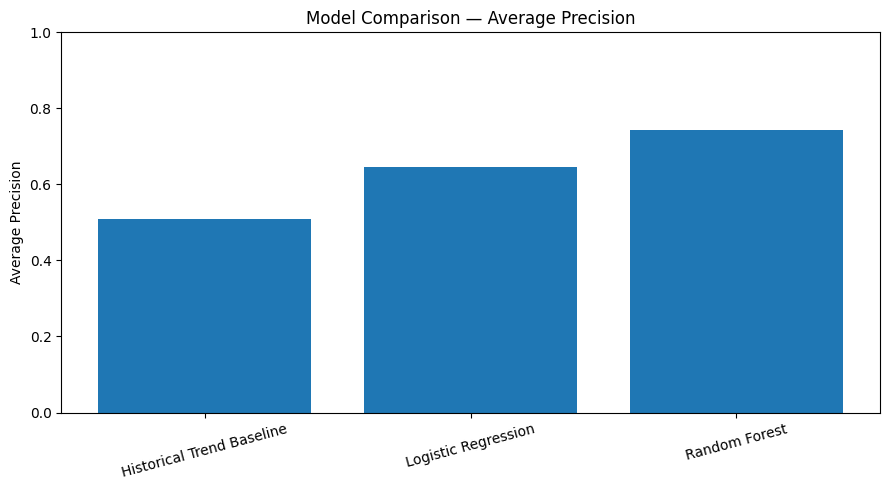

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["Average Precision"]
)

plt.ylabel("Average Precision")
plt.title("Model Comparison — Average Precision")
plt.ylim(0, 1)

plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

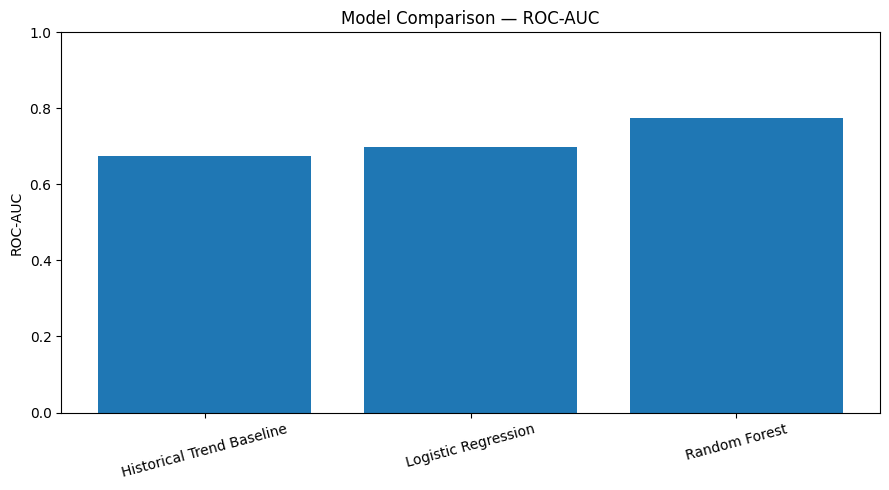

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["ROC-AUC"]
)

plt.ylabel("ROC-AUC")
plt.title("Model Comparison — ROC-AUC")
plt.ylim(0, 1)

plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    "feature": model_features,
    "importance": final_rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

print(feature_importance)

              feature  importance
0   impression_change    0.277145
1        avg_position    0.138626
2    last_impressions    0.122946
3   total_impressions    0.109225
4             avg_ctr    0.062379
5      first_position    0.061638
6       last_position    0.056949
7   first_impressions    0.056204
8     position_change    0.038646
9        total_clicks    0.035751
10        last_clicks    0.025397
11     history_months    0.011781
12       first_clicks    0.003313


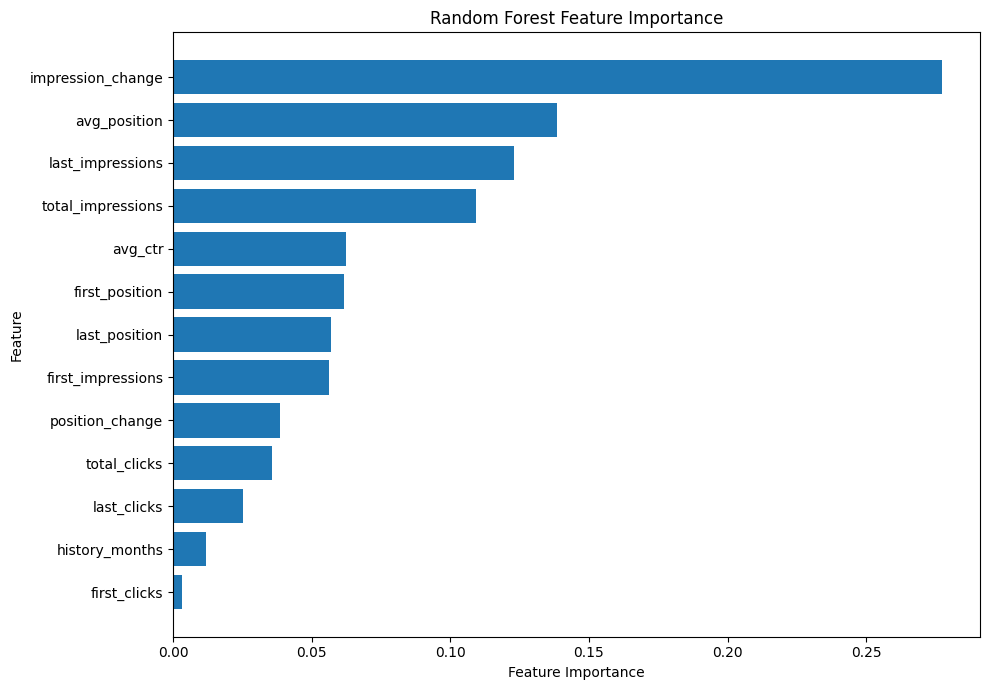

In [ ]:
plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

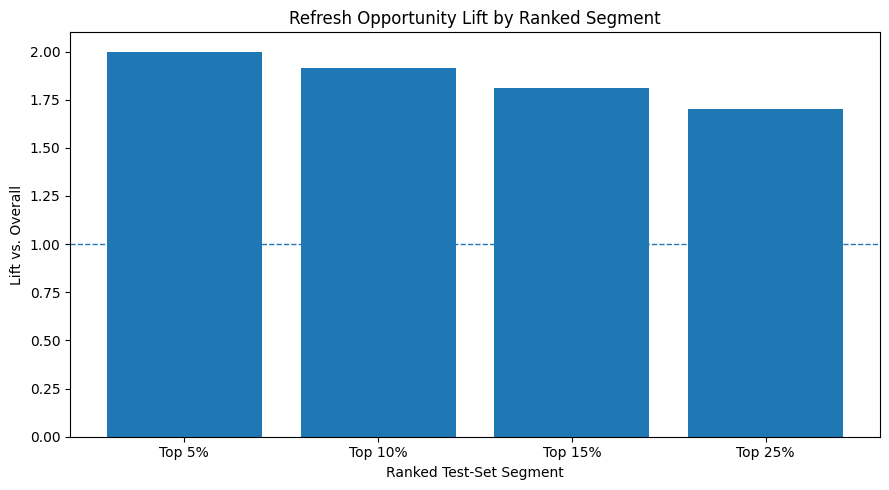

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    lift_table["segment"],
    lift_table["lift_vs_overall"]
)

plt.axhline(
    y=1,
    linestyle="--",
    linewidth=1
)

plt.ylabel("Lift vs. Overall")
plt.xlabel("Ranked Test-Set Segment")
plt.title("Refresh Opportunity Lift by Ranked Segment")

plt.tight_layout()

plt.show()

In [ ]:
final_recommendations = ranked_content[
    [
        "priority_rank",
        "client_hash_id",
        "content_hash_id",
        "priority",
        "recommended_action",
        "opportunity_score",
        "historical_avg_monthly_impressions",
        "future_avg_monthly_impressions",
        "future_impression_change",
        "avg_position",
        "avg_ctr",
        "impression_change",
        "position_change"
    ]
].copy()

final_recommendations = final_recommendations.head(100)

print(
    final_recommendations.to_string(index=False)
)

 priority_rank          client_hash_id          content_hash_id      priority recommended_action  opportunity_score  historical_avg_monthly_impressions  future_avg_monthly_impressions  future_impression_change  avg_position  avg_ctr  impression_change  position_change
             1 client_9958f0a7ae1df715 content_0457310428cc47ce High Priority            Refresh           0.990836                              3532.4                       86.333333                 -0.975560     33.482741 0.005562          -0.990291        43.893204
             2 client_9958f0a7ae1df715 content_b53af52dec1ef519 High Priority            Refresh           0.990615                              6181.2                      125.333333                 -0.979723     19.974285 0.004108          -0.998408         4.047771
             3 client_9958f0a7ae1df715 content_25a71c3076b62c43 High Priority            Refresh           0.989697                              6311.2                       33.333333          

In [ ]:
final_recommendations.to_csv(
    "capstone_top_100_recommendations.csv",
    index=False
)

print("Saved:", len(final_recommendations), "recommendations")

Saved: 100 recommendations


In [ ]:
recommendation_summary = (
    ranked_content
    .groupby(
        ["priority", "recommended_action"],
        observed=True
    )
    .agg(
        content_count=("content_hash_id", "count"),
        avg_opportunity_score=("opportunity_score", "mean"),
        avg_historical_impressions=(
            "historical_avg_monthly_impressions",
            "mean"
        ),
        avg_historical_impression_change=(
            "impression_change",
            "mean"
        )
    )
    .reset_index()
)

print(
    recommendation_summary.to_string(index=False)
)

     priority recommended_action  content_count  avg_opportunity_score  avg_historical_impressions  avg_historical_impression_change
      Monitor            Monitor          51308               0.301538                 2069.210052                         12.382440
       Review             Review          21379               0.554678                 1133.849356                          3.328791
High Priority            Refresh          12827               0.799343                 1235.876864                          0.328840


In [ ]:
action_playbook = pd.DataFrame({
    "priority": [
        "High Priority",
        "Review",
        "Monitor"
    ],
    "recommended_action": [
        "Refresh",
        "Review",
        "Monitor"
    ],
    "decision_rule": [
        "Top 15% of opportunity scores",
        "Next 25% of opportunity scores",
        "Bottom 60% of opportunity scores"
    ],
    "recommended_next_step": [
        "Review content freshness, search intent alignment, topical coverage, and internal linking. Prioritize pages with meaningful historical visibility.",
        "Perform a manual content and performance review before deciding whether a refresh is justified.",
        "Continue monitoring historical search-performance signals and reassess during the next review cycle."
    ]
})

print(action_playbook.to_string(index=False))

     priority recommended_action                    decision_rule                                                                                                                              recommended_next_step
High Priority            Refresh    Top 15% of opportunity scores Review content freshness, search intent alignment, topical coverage, and internal linking. Prioritize pages with meaningful historical visibility.
       Review             Review   Next 25% of opportunity scores                                                    Perform a manual content and performance review before deciding whether a refresh is justified.
      Monitor            Monitor Bottom 60% of opportunity scores                                               Continue monitoring historical search-performance signals and reassess during the next review cycle.


In [ ]:
evidence_table = ranked_content[
    [
        "priority_rank",
        "content_hash_id",
        "priority",
        "recommended_action",
        "opportunity_score",
        "historical_avg_monthly_impressions",
        "avg_position",
        "avg_ctr",
        "impression_change",
        "position_change"
    ]
].head(20).copy()

print(
    evidence_table.to_string(index=False)
)

 priority_rank          content_hash_id      priority recommended_action  opportunity_score  historical_avg_monthly_impressions  avg_position  avg_ctr  impression_change  position_change
             1 content_0457310428cc47ce High Priority            Refresh           0.990836                              3532.4     33.482741 0.005562          -0.990291        43.893204
             2 content_b53af52dec1ef519 High Priority            Refresh           0.990615                              6181.2     19.974285 0.004108          -0.998408         4.047771
             3 content_25a71c3076b62c43 High Priority            Refresh           0.989697                              6311.2     19.151077 0.006066          -0.990581         9.381476
             4 content_e802d6e7a49c9bc1 High Priority            Refresh           0.989563                              6613.4     19.468510 0.007729          -0.989796        13.421283
             5 content_c1d7772eada473df High Priority            

## Exporting the Recommendation Outputs

The final ranked results are exported into CSV files for further inspection and reuse.

Two outputs are produced:

- `capstone_top_100_recommendations.csv` — a compact list of the highest-ranked recommendations.
- `capstone_ranked_content.csv` — the complete ranked dataset containing all **85,514** modeling observations.

These outputs are intended for analysis and prioritization. They do not contain client names, domains, URLs, private search queries, credentials, or other identifying information.

In [ ]:
ranked_content.to_csv(
    "capstone_ranked_content.csv",
    index=False
)

print(
    "Saved complete ranked dataset:",
    len(ranked_content),
    "rows"
)

Saved complete ranked dataset: 85514 rows


## Leakage Audit

A major risk in retrospective prediction is accidentally allowing future outcome information to enter the model features.

To address this, the final feature list is explicitly compared against the future outcome columns.

The audit checks whether any of the following future variables are included as model features:

- Future months
- Future impressions
- Future clicks
- Future average position
- Future average CTR
- Future impression change
- Refresh opportunity label

The leakage audit returns an empty list.

### Result

**PASS — No future outcome columns are included in the model features.**

This confirms that the feature matrix uses historical information only, while the future period is reserved for outcome measurement.

In [ ]:
future_columns = [
    "future_months",
    "future_impressions",
    "future_clicks",
    "future_avg_position",
    "future_avg_ctr",
    "future_impression_change",
    "refresh_opportunity"
]

leakage_check = [
    column for column in model_features
    if column in future_columns
]

print("Potential future-data leakage:", leakage_check)

if len(leakage_check) == 0:
    print("PASS — No future outcome columns are included in model features.")
else:
    print("WARNING — Review the feature list.")

Potential future-data leakage: []
PASS — No future outcome columns are included in model features.


# Final Findings and Conclusion

This capstone tested whether historical search-performance signals could support the prioritization of content refresh opportunities.

The analysis used monthly content-performance data and separated historical information from a later outcome period. A refresh opportunity was defined as a decline of at least 50% in future average monthly impressions compared with the historical monthly average.

Three approaches were compared:

1. A transparent historical-trend baseline.
2. Logistic Regression.
3. Random Forest.

Random Forest produced the strongest overall machine-learning performance, achieving an Average Precision of **0.7436** and ROC-AUC of **0.7748** on the held-out client-group test set.

The ranking analysis also showed strong concentration of opportunities near the top of the model ranking. The top 15% of the held-out ranking achieved **82.73% precision**, compared with an overall opportunity rate of **45.64%**, producing approximately **1.81× lift**.

The results suggest that historical search-performance signals can be useful for prioritizing which content deserves closer review.

However, the findings should be interpreted carefully. This is a retrospective analysis, not a live production prediction system. The final full-data ranking is generated after fitting the model on the complete retrospective dataset, so those scores are not independent out-of-sample predictions.

Most importantly, the analysis does not prove that refreshing a page will cause search performance to recover, and it does not claim to reproduce or predict Google's ranking algorithm.

The appropriate interpretation is:

> **The model is a decision-support tool for prioritizing content review based on historical search-performance patterns.**

# Reproducibility

This project was developed using Python and standard machine-learning tools, including pandas and scikit-learn.

The notebook contains the complete workflow from data loading and aggregation through feature engineering, baseline construction, model training, validation, leakage auditing, ranking, and recommendation generation.

### Main reproducibility points

- Historical period: November 2025 – March 2026
- Future evaluation period: April 2026 – June 2026
- Minimum historical coverage: 3 months
- Future coverage requirement: all 3 future months
- Target: future monthly impressions decline of at least 50%
- Validation: client-grouped 80/20 holdout
- Main model: Random Forest
- Random Forest: 200 trees, maximum depth 10, minimum leaf size 5
- Random seed: 42
- Final modeling population: 85,514 observations

The complete project repository contains the notebook, research paper, and generated recommendation outputs.

The final deployed research paper provides the public-facing summary of the methodology, results, limitations, and action playbook.

# Acknowledgments & Data Credit

This project was completed as part of the **FlyRank ML Internship** and uses the internship's anonymized search-performance dataset.

**Built on the FlyRank ML Internship dataset.**

The analysis follows the public-safety principles provided with the internship materials. Client names, domains, URLs, private search queries, credentials, and raw private exports are not included in the public-facing project.

The results are presented as observed and measured patterns for decision support. They should not be interpreted as claims about Google's ranking algorithm or as evidence that a particular content refresh will cause a ranking or traffic recovery.